## Image Processing Using OpenCV

#### 1. Changing Colorspaces
Learn to change images between different color spaces. Plus learn to track a colored object in a video.

In [1]:
#Color Conversion
# For color conversion, we use the function cv.cvtColor(input_image, flag) where flag determines the type of conversion.
import cv2 as cv
flags = [i for i in dir(cv) if i.startswith('COLOR_')]
print( flags )

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

In [3]:
'''Object Tracking
Now that we know how to convert a BGR image to HSV, we can use this to extract a colored object. In HSV, it is easier to represent a color than in BGR color-space. In our application, we will try to extract a blue colored object. So here is the method:

Take each frame of the video
Convert from BGR to HSV color-space
We threshold the HSV image for a range of blue color
Now extract the blue object alone, we can do whatever we want on that image.'''

'Object Tracking\nNow that we know how to convert a BGR image to HSV, we can use this to extract a colored object. In HSV, it is easier to represent a color than in BGR color-space. In our application, we will try to extract a blue colored object. So here is the method:\n\nTake each frame of the video\nConvert from BGR to HSV color-space\nWe threshold the HSV image for a range of blue color\nNow extract the blue object alone, we can do whatever we want on that image.'

In [4]:
import cv2 as cv
import numpy as np
 
cap = cv.VideoCapture(0)
 
while(1):
 
    # Take each frame
    _, frame = cap.read()
 
    # Convert BGR to HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
 
    # define range of blue color in HSV
    lower_blue = np.array([110,50,50])
    upper_blue = np.array([130,255,255])
 
    # Threshold the HSV image to get only blue colors
    mask = cv.inRange(hsv, lower_blue, upper_blue)
 
    # Bitwise-AND mask and original image
    res = cv.bitwise_and(frame,frame, mask= mask)
 
    cv.imshow('frame',frame)
    cv.imshow('mask',mask)
    cv.imshow('res',res)
    k = cv.waitKey(5) & 0xFF
    if k == 27:
        break
 
cv.destroyAllWindows()

KeyboardInterrupt: 

In [5]:
#How to find HSV values to track?
green = np.uint8([[[0,255,0 ]]])
hsv_green = cv.cvtColor(green,cv.COLOR_BGR2HSV)
print( hsv_green )


[[[ 60 255 255]]]


In [6]:
#Try to find a way to extract more than one colored object, for example, extract red, blue, and green objects simultaneously.

import cv2
import numpy as np

# Load image
image = cv2.imread('WIN_20250215_22_04_06_Pro.jpg')
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define color ranges (HSV)
# Red has two ranges due to hue wrapping around at 180
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

lower_green = np.array([36, 50, 70])
upper_green = np.array([89, 255, 255])

lower_blue = np.array([90, 50, 70])
upper_blue = np.array([128, 255, 255])

# Create masks for each color
mask_red = cv2.inRange(hsv, lower_red1, upper_red1) | cv2.inRange(hsv, lower_red2, upper_red2)
mask_green = cv2.inRange(hsv, lower_green, upper_green)
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Combine masks
combined_mask = cv2.bitwise_or(mask_red, cv2.bitwise_or(mask_green, mask_blue))

# Apply the mask
result = cv2.bitwise_and(image, image, mask=combined_mask)

# Show the result
cv2.imshow('Original', image)
cv2.imshow('Extracted Colors', result)
cv2.waitKey(0)
cv2.destroyAllWindows()


### Geometric Transformations of Images
OpenCV provides two transformation functions, cv.warpAffine and cv.warpPerspective, with which you can perform all kinds of transformations. cv.warpAffine takes a 2x3 transformation matrix while cv.warpPerspective takes a 3x3 transformation matrix as input.

In [ ]:
'''Scaling
Scaling is just resizing of the image. OpenCV comes with a function cv.resize() for this purpose. The size of the image can be specified manually, or you can specify the scaling factor. Different interpolation methods are used. Preferable interpolation methods are cv.INTER_AREA for shrinking and cv.INTER_CUBIC (slow) & cv.INTER_LINEAR for zooming. By default, the interpolation method cv.INTER_LINEAR is used for all resizing purposes.
You can resize an input image with either of following methods:
'''

In [14]:
img = cv.imread('WIN_20250215_22_04_06_Pro.jpg')
assert img is not None, "file could not be read, check with os.path.exists()"
  
"""height, width = img.shape[:2]
res = cv.resize(img,(2*width, 2*height), interpolation = cv.INTER_CUBIC)"""
res = cv.resize(img,None,fx=2, fy=2, interpolation = cv.INTER_CUBIC)
cv.imshow("Resized Image", res)
cv.waitKey(0)  # Waits for a key press
cv.destroyAllWindows()

In [16]:
#Translation
img = cv.imread('WIN_20250215_22_04_06_Pro.jpg')
assert img is not None, "file could not be read, check with os.path.exists()"
  
rows, cols= img.shape[:2]
M = np.float32([[1,0,100],[0,1,50]])
dst = cv.warpAffine(img,M,(cols,rows))

cv.imshow('img',dst)
cv.waitKey(0)
cv.destroyAllWindows()

In [18]:
#Rotation of the Image

M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
dst = cv.warpAffine(img,M,(cols,rows))
cv.imshow('img',dst)
cv.waitKey(0)
cv.destroyAllWindows()

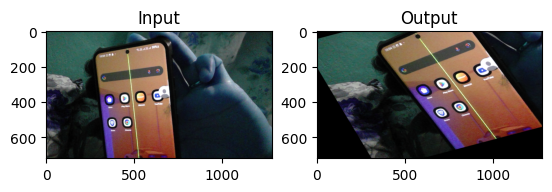

In [ ]:
import matplotlib as mat
import matplotlib.pyplot as plt
#Affine Transformation
'''In affine transformation, all parallel lines in the original image will still
be parallel in the output image. To find the transformation matrix, we need three 
points from the input image and their corresponding locations in the output image. 
Then cv.getAffineTransform will create a 2x3 matrix which is to be passed to cv.
warpAffine.'''
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
 
M = cv.getAffineTransform(pts1,pts2)
 
dst = cv.warpAffine(img,M,(cols,rows))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

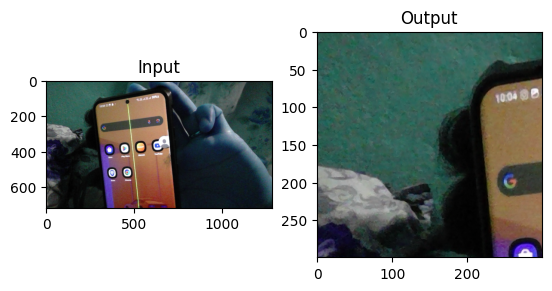

In [21]:
'''Perspective Transformation
For perspective transformation, you need a 3x3 transformation matrix. Straight 
lines will remain straight even after the transformation. To find this 
transformation matrix, you need 4 points on the input image and corresponding points on the output image. Among these 4 points, 3 of them should 
not be collinear. Then the transformation matrix can be found by the function cv.getPerspectiveTransform. Then apply cv.warpPerspective with this 3x3 
transformation matrix.'''
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
 
M = cv.getPerspectiveTransform(pts1,pts2)
 
dst = cv.warpPerspective(img,M,(300,300))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()



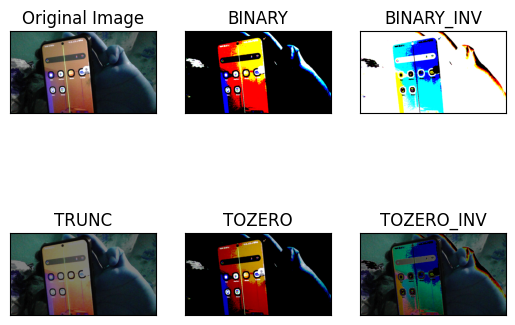

In [22]:
#Simple Thresholding
'''Here, the matter is straight-forward. For every pixel, the same threshold value is applied. If the pixel value is smaller than or equal to the threshold, it is set to 0, otherwise it is set to a maximum value. The function cv.threshold is used to apply the thresholding. The first argument is the source image, which should be a grayscale image. The second argument is the threshold value which is used to classify the pixel values
Basic thresholding as described above is done by using the type cv.THRESH_BINARY. All simple thresholding types are:

cv.THRESH_BINARY
cv.THRESH_BINARY_INV
cv.THRESH_TRUNC
cv.THRESH_TOZERO
cv.THRESH_TOZERO_INV'''
assert img is not None, "file could not be read, check with os.path.exists()"
ret,thresh1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,127,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,127,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,127,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
 
plt.show()

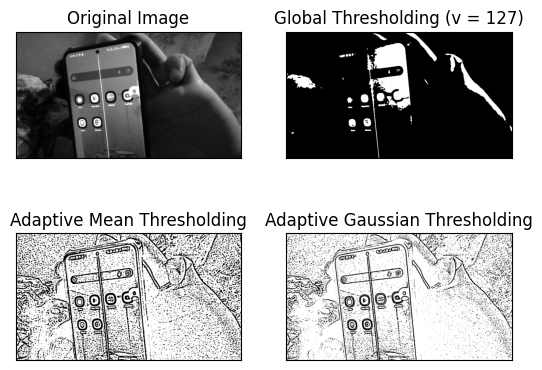

In [24]:
#Adaptive Thresholding
'''The adaptiveMethod decides how the threshold value is calculated:

cv.ADAPTIVE_THRESH_MEAN_C: The threshold value is the mean of the neighbourhood area minus the constant C.
cv.ADAPTIVE_THRESH_GAUSSIAN_C: The threshold value is a gaussian-weighted sum of the neighbourhood values minus the constant C.'''
img = cv.imread('WIN_20250215_22_04_06_Pro.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)
 
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
 
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
 
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

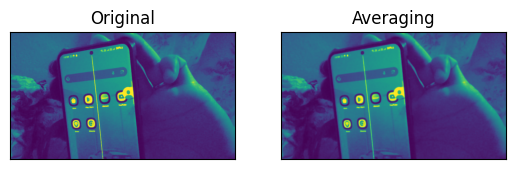

In [28]:
## Smoothing Images
'''Goals
Learn to:

Blur images with various low pass filters
Apply custom-made filters to images (2D convolution)
2D Convolution ( Image Filtering )
As in one-dimensional signals, images also can be filtered with various low-pass filters (LPF), high-pass filters (HPF), etc. LPF helps in removing noise, blurring images, etc. HPF filters help in finding edges in images.

OpenCV provides a function cv.filter2D() to convolve a kernel with an image. As an example, we will try an averaging filter on an image. A 5x5 averaging filter kernel will look like the below:
'''
kernel = np.ones((5,5),np.float32)/25
dst = cv.filter2D(img,-1,kernel)
 
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()